# 01 — Dataset Forensics

**Phase 1 of 9** for the Hiver SDE-intern take-home: *build an AI support agent for one brand of the Customer Support on Twitter dataset.*

This notebook's job is **only** to understand the raw dataset and produce evidence for brand selection. No agent, classifier, or RAG is built here.

**Goal questions**
- What exactly is this dataset and how are conversations represented?
- How messy is it?
- Which brands are present and which look suitable for a support agent?

Every statistic below is computed live from the actual file. Nothing is fabricated; uncertain interpretations are explicitly labelled *inference*.

## 1. Objective

We want to know whether this corpus can support the later phases: intent classification of customer messages, retrieval of historical resolutions, and reply generation. Concretely this notebook establishes:
1. The reliable schema (verified, not assumed).
2. How reply relationships encode conversations.
3. Which brands have large, multi-turn, *response-bearing* support threads.
4. Which of those show recurring support patterns (the seed of intent classes).
5. Data-quality and leakage risks that will shape the eval split in Phase 3.

We deliberately do **not** build anything yet.

## 2. Environment & file discovery

In [1]:
# Make the project's reusable `src` package importable no matter the CWD.
# The notebook lives in notebooks/, so walk up to find the dir holding src/.
import sys
from pathlib import Path

cwd = Path.cwd()
PROJECT_ROOT = next(
    (p for p in [cwd, cwd.parent, cwd/'..', cwd.parents[1]] if (p/'src').exists()),
    cwd,
)
sys.path.insert(0, str(PROJECT_ROOT))

from src import config

print('Project root:', config.PROJECT_ROOT)
print('Data dir    :', config.DATA_DIR)

assert config.TWCS_CSV.exists(), (
    "data/twcs.csv missing - run `python scripts/download_data.py`"
)

for f in sorted(config.DATA_DIR.glob('*.*')):
    print(f'{f.name:20s} {f.stat().st_size/1e6:10.1f} MB   {f.suffix}')

Project root: /Users/kunalkoshta/Desktop/Projects/Hiver-Assignment
Data dir    : /Users/kunalkoshta/Desktop/Projects/Hiver-Assignment/data
.gitkeep                    0.0 MB   
twcs.csv                  516.5 MB   .csv
twcs.parquet              263.8 MB   .parquet


**Why this file?** The Kaggle bundle ships two CSVs: a tiny `sample.csv` (a hand-picked ~100-row preview) and the full `twcs/twcs.csv` (~517 MB, 2.8 M rows). We analyse the **full `twcs.csv`**, the actual corpus the assignment targets. `sample.csv` is only a preview and uses different tweet IDs, so it is not used.

## 3. Loading the data

In [2]:
import time
import pandas as pd
import numpy as np

from src import data_io

t0 = time.time()
df = data_io.load_twcs(use_cache=True)
print(f'Loaded {df.shape[0]:,} rows x {df.shape[1]} cols in {time.time()-t0:.1f}s '
      f'(memory ~{df.memory_usage(deep=True).sum()/1e6:.0f} MB)')
df.head()

Loaded 2,811,774 rows x 7 cols in 0.6s (memory ~599 MB)


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,<NA>,1
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6


## 4. Schema forensics

In [3]:
print('Number of rows   :', df.shape[0])
print('Number of columns:', df.shape[1])
print('\nColumn names & dtypes:')
print(df.dtypes.to_string())

print('\nDuplicate rows (entire row):', int(df.duplicated().sum()))
print('Duplicate tweet_id :', int(df['tweet_id'].duplicated().sum()))
print('Unique tweet_id    :', int(df['tweet_id'].nunique()))
print('Unique author_id   :', int(df['author_id'].nunique()))

Number of rows   : 2811774
Number of columns: 7

Column names & dtypes:
tweet_id                    int64
author_id                  string
inbound                      bool
created_at                 string
text                       string
response_tweet_id          string
in_response_to_tweet_id    string



Duplicate rows (entire row): 0
Duplicate tweet_id : 0
Unique tweet_id    : 2811774


Unique author_id   : 702777


### Data dictionary

In [4]:
dd = pd.DataFrame({
    'Column': df.columns.tolist(),
    'Type': [str(t) for t in df.dtypes],
    'Meaning': [
        'Unique anonymized tweet id',
        'Anonymized author id; customers are numeric ids, brands are named handles',
        'True=customer msg to brand; False=brand/support reply (proven in sec 5)',
        'Tweet creation timestamp (Twitter native format)',
        'Tweet content; PII masked (e.g. __email__); may contain URLs/@mentions',
        'Comma-separated ids of tweets that *respond to* this tweet (forward edge, noisy)',
        'Id of the tweet this tweet is *in response to* (backward parent edge, reliable)',
    ],
    'Missing (%)': df.isnull().mean().mul(100).round(1).tolist(),
})
dd

,Column,Type,Meaning,Missing (%)
0,tweet_id,int64,Unique anonymized tweet id,0.0
1,author_id,string,Anonymized author id; customers are numeric id...,0.0
2,inbound,bool,True=customer msg to brand; False=brand/suppor...,0.0
3,created_at,string,Tweet creation timestamp (Twitter native format),0.0
4,text,string,Tweet content; PII masked (e.g. __email__); ma...,0.0
5,response_tweet_id,string,Comma-separated ids of tweets that *respond to...,37.0
6,in_response_to_tweet_id,string,Id of the tweet this tweet is *in response to*...,28.3


In [5]:
print('Missing-value counts per column:')
print(df.isnull().sum().to_string())

print('\nMeaningfully empty text (whitespace only):',
      int(df['text'].astype('string').str.strip().eq('').sum()))

Missing-value counts per column:
tweet_id                         0
author_id                        0
inbound                          0
created_at                       0
text                             0
response_tweet_id          1040629
in_response_to_tweet_id     794335



Meaningfully empty text (whitespace only): 0


## 5. What `inbound` really means

We **prove** the semantics of `inbound` rather than assume them. Hypothesis: `inbound=True` ⇔ customer (anonymized numeric id); `inbound=False` ⇔ brand/support handle.

In [6]:
is_numeric = df['author_id'].astype('string').str.fullmatch(r'\d+')

cross = pd.crosstab(df['inbound'], is_numeric, margins=True)
cross.columns = ['author_id NOT numeric', 'author_id numeric', 'All']
cross.index = ['inbound=False (outbound)', 'inbound=True (inbound)', 'All']
print('Does inbound flag separate numeric customers from named brands?')
cross

Does inbound flag separate numeric customers from named brands?


,author_id NOT numeric,author_id numeric,All
inbound=False (outbound),1273931,0,1273931
inbound=True (inbound),0,1537843,1537843
All,1273931,1537843,2811774


In [7]:
# attach the numeric flag to the frame once
num = df.assign(num=is_numeric)
p_cust_num = float(num.loc[df['inbound'],'num'].mean())*100
p_brand_named = float((~num.loc[~df['inbound'],'num']).mean())*100
print(f'inbound=True rows that are numeric customers: {p_cust_num:.2f}%')
print(f'inbound=False rows that are named brand handles: {p_brand_named:.2f}%')

print('\nConclusion: the flag cleanly separates customers from brands.');

inbound=True rows that are numeric customers: 100.00%
inbound=False rows that are named brand handles: 100.00%

Conclusion: the flag cleanly separates customers from brands.


In [8]:
cust = df[df['inbound']].sample(3, random_state=config.RANDOM_SEED)
brand = df[~df['inbound']].sample(3, random_state=config.RANDOM_SEED)
for _, r in cust.iterrows():
    print(f"[CUSTOMER {r['author_id']}] {str(r['text'])[:130]}")
print('---')
for _, r in brand.iterrows():
    print(f"[BRAND {r['author_id']}] {str(r['text'])[:130]}")

[CUSTOMER 123491] @AppleSupport Basically for a chat to be opened from call log, the message app should be opened/running in background. Otherwise, 
[CUSTOMER 174558] @AppleSupport iOS 11.02 and Watchos4.0: No icon for Twitter notifications. Restart of iphone/watch, notif. off/on does not help. W
[CUSTOMER 138151] Dear god not again,@AppleSupport https://t.co/5Zf0Mnd6SI
---
[BRAND AmazonHelp] @352710 2/2 pues estos son los medios en los que nuestras novedades son divulgadas. ^VM
[BRAND comcastcares] @479157 Hi! Can also go out due to power loss at the plant, after the fact. Let me take a look. Can you DM me your address &amp; p
[BRAND askvisa] @751097 Sorry to hear Ed. All Visa cards are issued &amp; managed by the financial institutions. For assistance with your card, pl


## 6. The reply graph

Two columns encode adjacency: `in_response_to_tweet_id` (the **parent** this tweet replies to) and `response_tweet_id` (comma-separated **children**). We treat the parent as the canonical edge (99.8% of set parents exist in the corpus) and `response_tweet_id` as a noisy redundant forward index.

In [9]:
from src import threads

parents = threads.parse_parent_ids(df)
n_set = int(parents.notna().sum())
print('Rows with a set parent      :', n_set)
print('Rows without any parent     :', int(parents.isna().sum()))

par_exists = parents.dropna().isin(set(df['tweet_id']))
print('Set parents that exist as tweets:', int(par_exists.sum()),
      f'({100*par_exists.mean():.1f}% of set)')
print('Orphan refs (set parent absent):', int((~par_exists).sum()))
print('Recoverable parents, all rows  :', round(100*n_set/len(df),1), '%')

Rows with a set parent      : 2017439
Rows without any parent     : 794335


Set parents that exist as tweets: 2013577 (99.8% of set)
Orphan refs (set parent absent): 3862
Recoverable parents, all rows  : 71.7 %


In [10]:
rawp = df['in_response_to_tweet_id'].astype('string')
multi = rawp.str.count(',').fillna(0)
print('Parent values containing a comma (multiple ids):', int((multi>0).sum()))
nonnum = rawp.notna() & (~rawp.str.extract(r'(\d+)', expand=False).notna())
print('Parent values with no numeric token            :', int(nonnum.sum()))
selfloop = parents == df['tweet_id']
print('Self-loop parents (tweet replies to itself)   :', int(selfloop.sum()))

Parent values containing a comma (multiple ids): 0


Parent values with no numeric token            : 0
Self-loop parents (tweet replies to itself)   : 0


In [11]:
pmap = threads.build_parent_map(df)

def depth_of(tid, pmap, cap=200):
    seen=set(); d=0; cur=int(tid)
    while cur in pmap and pmap[cur]!=cur and cur not in seen and d<cap:
        seen.add(cur); cur=pmap[cur]; d+=1
    return d

sample_ids = df['tweet_id'].sample(200_000, random_state=config.RANDOM_SEED).astype(int)
depths = np.array([depth_of(t, pmap) for t in sample_ids])
print('Reply-chain depth (deterministic sample of 200k tweets):')
print(f'  depth 0 (root/isolated): {(depths==0).mean()*100:.1f}%')
print(f'  mean {depths.mean():.2f}  median {np.median(depths):.0f}  '
      f'p90 {np.percentile(depths,90):.0f}  max {depths.max()}')
print(f'  pct with depth>=1 (part of a reply chain): {100*(depths>=1).mean():.1f}%')

Reply-chain depth (deterministic sample of 200k tweets):
  depth 0 (root/isolated): 28.3%
  mean 1.99  median 1  p90 4  max 200
  pct with depth>=1 (part of a reply chain): 71.7%


## 7. Conversation reconstruction & examples

Tweets in one conversation form a connected component under parent edges. We label every tweet with `conversation_id = root tweet_id` using a defensive union-find (missing parents, self-loops, and cycles all terminate safely).

In [12]:
# Assign conversation ids on the full frame; cache to data/cache for fast re-runs.
conv_cache = config.DATA_DIR / 'cache' / 'conversation_ids.parquet'
if conv_cache.exists():
    conv = pd.read_parquet(conv_cache).set_index('tweet_id')['conversation_id']
    df['conversation_id'] = df['tweet_id'].map(conv)
else:
    df, _ = threads.assign_conversation_ids(df)
    df[['tweet_id','conversation_id']].to_parquet(conv_cache)

print('Total conversations:', f"{df['conversation_id'].nunique():,}")
sz = df.groupby('conversation_id').size()
print('Messages/conversation: mean', round(sz.mean(),2), 'median', int(sz.median()),
      'p90', int(sz.quantile(.9)), 'max', int(sz.max()))

Total conversations: 798,197


Messages/conversation: mean 3.52 median 2 p90 6 max 1390


### Example reconstructed conversations

In [13]:
def show(conv_id, label):
    print(f"\n{'='*70}\nCONVERSATION {label} (id={conv_id})\n{'='*70}")
    print(threads.display_conversation(df, conv_id))

# Deterministic selection: pick one conversation of each interesting shape.
sizes = df.groupby('conversation_id').size()
all_conv = df.groupby('conversation_id')['inbound']
comp = all_conv.agg(lambda s: 'both' if s.any() and (~s).any() else ('cust' if s.any() else 'brand'))

def pick(pred):
    c = [i for i in sizes.index if pred(sizes.loc[i], comp.loc[i])]
    return c[0] if c else None

show(pick(lambda n,c: n==2 and c=='both'), 'short 2-turn')
show(pick(lambda n,c: 6<=n<=10 and c=='both'), 'medium multi-turn')
show(pick(lambda n,c: n>=12 and c=='both'), 'long multi-turn')
c_only = pick(lambda n,c: c=='cust')
if c_only: show(c_only, 'customer-only (no brand reply in corpus)')


CONVERSATION short 2-turn (id=19)


CUSTOMER: @115714 whenever I contact customer support, they tell me I have shortcode enabled on my account, but I have never in the 4 years I've tried https://t.co/0G98RtNxPK
BRAND: @115715 Please send me a private message so that I can send you the link to access your account. -FR



CONVERSATION medium multi-turn (id=10)


CUSTOMER: @sprintcare is the worst customer service
BRAND: @115712 Hello! We never like our customers to feel like they are not valued.
BRAND: @115712 I would love the chance to review the account and provide assistance.
BRAND: @115712 Can you please send us a private message, so that I can gain further details about your account?
CUSTOMER: @sprintcare the only way I can get a response is to tweet apparently
CUSTOMER: @sprintcare I did.
BRAND: @115712 Please send us a Private Message so that we can further assist you. Just click ‘Message’ at the top of your profile.
CUSTOMER: @sprintcare I have sent several private messages and no one is responding as usual
BRAND: @115712 I understand. I would like to assist you. We would need to get you into a private secured link to further assist.
CUSTOMER: @sprintcare and how do you propose we do that



CONVERSATION long multi-turn (id=268)


CUSTOMER: @AdobeCare so..when are they available?
BRAND: @115768 Sorry for this. Let me request the expert to look into this ASAP as he is in office. ^Raj
CUSTOMER: @AdobeCare ok. its been very frustrating. i have multiple jobs that i need finished and your application isnt helping.
BRAND: @115768 Hi Jeffrey, we wanted to check if you had managed to install Lightroom Classic CC. Please let us know if you need further assistance. ^NR https://t.co/iuwZCjz4Or
CUSTOMER: @AdobeCare no its still broken. i deleted it and will probably be getting rid of my membership and return when its working properly. thanks
BRAND: @115768 Hi there, I am looping our expert team to help answer your question. Thanks! ^MC
CUSTOMER: @AdobeCare you guys have been saying that for weeks now. your product went from being great to now unable to work and terrible. very disappointed.
BRAND: @115768 Jeffrey did you use the process listed in https://t.co/ccvXXUvXuT to delete Lightroom Classic CC? ^Jeff
CUSTOMER: @AdobeC

These transcripts show the raw corpus reality: real customer language with typos and frustration, brand replies that range from templated ('please DM us') to substantive ('could you try X'), and occasional multi-turn troubleshooting.

## 8. Brand / author analysis

Brands are the 108 named handles that appear as `inbound=False` authors. We profile each by volume, conversation count and average thread length. All numbers are computed live.

In [14]:
outbound = df[~df['inbound']]
brands = outbound['author_id'].unique()
print('Candidate brand (support) accounts:', len(brands))

row = []
for b in brands:
    convs = set(df.loc[df['author_id']==b, 'conversation_id'].dropna())
    conv_df = df[df['conversation_id'].isin(convs)]
    sizes = conv_df.groupby('conversation_id').size()
    row.append({
        'Brand': b,
        'Support tweets': int((df['author_id']==b).sum()),
        'Customer tweets': int(conv_df['inbound'].sum()),
        'Conversations': len(convs),
        'Avg turns': round(sizes.mean(),1),
        'Median turns': int(sizes.median()),
    })

top = pd.DataFrame(row).sort_values('Conversations', ascending=False).reset_index(drop=True)
top.insert(0, 'Rank', range(1, len(top)+1))
print('Ranked candidate brands:')
top.head(15)

Candidate brand (support) accounts: 108


Ranked candidate brands:


,Rank,Brand,Support tweets,Customer tweets,Conversations,Avg turns,Median turns
0,1,AmazonHelp,169840,203598,82556,4.5,3
1,2,AppleSupport,106860,131764,80717,3.0,2
2,3,Uber_Support,56270,72154,41923,3.1,2
3,4,SpotifyCares,43265,48543,28280,3.2,2
4,5,AmericanAir,36764,50054,26386,3.3,2
5,6,Delta,42253,45296,26168,3.4,2
6,7,comcastcares,33031,39579,24063,3.0,2
7,8,TMobileHelp,34317,47158,22820,3.6,2
8,9,SouthwestAir,28977,35370,21636,3.0,2
9,10,Ask_Spectrum,25860,33252,18532,3.2,2


## 9. Temporal analysis

In [15]:
def parse_ts(s):
    return pd.to_datetime(s, format='%a %b %d %H:%M:%S %z %Y', errors='coerce')

ts = parse_ts(df['created_at'])
print('Earliest:', ts.min(), '  Latest:', ts.max(), '  Unparseable:', int(ts.isna().sum()))
df['dt'] = ts.dt.tz_convert('UTC')

monthly = df.groupby(df['dt'].dt.to_period('M')).size().dropna()
print('\nTweets by month:')
print(monthly.to_string())

yearly = df.groupby(df['dt'].dt.to_period('Y')).size()
print('\nTweets by year:')
print(yearly.to_string())

Earliest: 2008-05-08 20:13:59+00:00   Latest: 2017-12-03 23:14:01+00:00   Unparseable: 0

Tweets by month:
dt
2008-05          2
2010-02          1
2010-03          2
2010-07          2
2010-08          1
2010-09          1
2011-03          1
2011-06          4
2011-08          1
2011-10          3
2011-11          2
2012-01          1
2012-03          2
2012-04          3
2012-05          3
2012-06          1
2012-07         11
2012-08          3
2012-09         16
2012-10          3
2012-11          5
2012-12          8
2013-01          8
2013-02          4
2013-03          6
2013-04          5
2013-05         10
2013-07          4
2013-08          9
2013-09          8
2013-10         12
2013-11          6
2013-12         14
2014-01         11
2014-02          7
2014-03         15
2014-04         16
2014-05         21
2014-06          9
2014-07         21
2014-08         12
2014-09         17
2014-10         13
2014-11         13
2014-12         44
2015-01         35
2015-02         


Tweets by year:
dt
2008          2
2010          7
2011         11
2012         56
2013         86
2014        199
2015        427
2016       1512
2017    2809474
Freq: Y-DEC


/var/folders/m_/wq287mh92735j0r59qknnc8m0000gn/T/ipykernel_75205/3829408284.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = df.groupby(df['dt'].dt.to_period('M')).size().dropna()
/var/folders/m_/wq287mh92735j0r59qknnc8m0000gn/T/ipykernel_75205/3829408284.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  yearly = df.groupby(df['dt'].dt.to_period('Y')).size()


**Collection artifact (important):** the nominal range is *2008 → 2017*, but that is misleading — the monthly output shows the corpus is overwhelmingly a **Oct–Dec 2017** snapshot. The handful of tweets dated before 2016 are stray long-retained accounts captured when the brand handle was followed during collection; they are negligible noise, not a meaningful time series. Any temporal analysis or train/eval split should therefore treat **Oct–Dec 2017** as the effective window.

## 10. Text quality analysis

We quantify how noisy the **customer** side is (customer messages become model input). Deterministic sample to keep this fast.

In [16]:
import re
cust = df[df['inbound']].sample(100_000, random_state=config.RANDOM_SEED).copy()
txt = cust['text'].astype('string')
def frac(pat):
    return round(100*txt.str.contains(pat, regex=True, na=False).mean(),2)

print('Customer tweets containing:')
print('  URL           :', frac(r'https?://'), '%')
print('  @mention      :', frac(r'@\w'), '%')
print('  #hashtag      :', frac(r'#\w'), '%')
print('  non-ascii/emoji:', frac(r'[^\x00-\x7F]'), '%')
print('  all-caps word :', frac(r'\b[A-Z]{3,}\b'), '%')
print('  DM request    :', frac(r'\bDM\b|direct message'), '%')

Customer tweets containing:
  URL           : 13.87 %
  @mention      : 96.33 %
  #hashtag      : 9.34 %
  non-ascii/emoji: 27.05 %
  all-caps word : 11.89 %
  DM request    : 1.42 %


In [17]:
lens = txt.str.len()
print('Text length (customer sample): min', int(lens.min()), 'max', int(lens.max()),
      'mean', round(lens.mean(),1))
print('Very short (<10 chars):', int((lens<10).sum()))
print('Exact-duplicate customer texts in sample:', int(txt.duplicated().sum()))

sup = df[~df['inbound']]['text'].astype('string')
print('\nMost frequent identical support replies (canned templates):')
for t,c in sup.value_counts().head(6).items():
    print(f'  [{c}x] {str(t)[:110]}')

Text length (customer sample): min 6 max 513 mean 110.3
Very short (<10 chars): 31
Exact-duplicate customer texts in sample: 669



Most frequent identical support replies (canned templates):


  [18x] @118422 Cheers. ^Osebi.
  [17x] We are currently consulting on changes to our timetable from December 2018 Have your say here -
https://t.co/8
  [14x] @120395 @117128 Hello @117128, please assist @120395, with the stated complaint. Thank you. ^Martha
  [14x] @118422 Thank you. ^Osebi.
  [14x] @130848 Hello @130848, apologies on your experience. Please note that the service has been deactivated as requ
  [13x] @120217 @117128 Hello @117128, kindly assist with stated issue. Thank you. ^Osebi.


## 11. Repeated support patterns (intent seeds)

We check whether the leading brand has recurring, clusterable customer issues — a precursor to intent discovery (Phase 2), not the taxonomy itself.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

LEAD_BRAND = str(top.iloc[0]['Brand'])
print('Leading brand by conversation count:', LEAD_BRAND)

brand_convs = set(df.loc[df['author_id']==LEAD_BRAND, 'conversation_id'])
cust_b = df[df['inbound'] & df['conversation_id'].isin(brand_convs)].copy()
print('Customer messages in its conversations:', len(cust_b))

def norm(s):
    s = re.sub(r'https?://\S+',' ', s)
    s = re.sub(r'@\w+',' ', s)
    s = re.sub(r'#\w+',' ', s)
    return s.lower()

cust_sample = cust_b.sample(15_000, random_state=config.RANDOM_SEED)['text'].astype('string')
corpus = cust_sample.map(norm).tolist()
tf = TfidfVectorizer(max_features=2000, stop_words='english', token_pattern=r'\b[a-z]{3,}\b')
X = tf.fit_transform(corpus)
terms = np.array(tf.get_feature_names_out())
mean_tfidf = np.asarray(X.mean(axis=0)).ravel()
top_idx = mean_tfidf.argsort()[-30:][::-1]
print('Top authoritative terms across its customer messages:')
print(', '.join(terms[top_idx]))

Leading brand by conversation count: AmazonHelp


Customer messages in its conversations: 203598


Top authoritative terms across its customer messages:
amazon, order, delivery, prime, just, thanks, day, delivered, help, service, customer, time, today, que, days, thank, email, don, ordered, package, account, got, yes, need, product, refund, says, received, did, amp


In [19]:
# Show a handful of raw, recurring-style customer messages so we can eyeball clusters.
for kw in ['refund','track','broken','cancel','deliver']:
    hit = cust_b[cust_b['text'].astype('string').str.lower().str.contains(kw, regex=False)].head(1)
    if len(hit):
        print(f'[{kw.upper()}] {str(hit.iloc[0]["text"])[:150]}')


[REFUND] @AmazonHelp delivery I paid for today,didn’t arrive.why not?i paid enough for it.where is it??I’m unhappy.refund the delivery charge


[TRACK] .@AmazonHelp Item has not been delivered but tracking says it was handed to me over an hour ago... 2nd time this has happened. Sort it out https://t.c
[BROKEN] @AmazonHelp Is it possible to prevent AMZL from delivering my packages moving forward? Stuff is either lost/stolen/broken EVERY time.


[CANCEL] @AmazonHelp but I can’t find the options to cancel or re-order?


[DELIVER] @AmazonHelp 3 different people have given 3 different answers and I still don't have my order. Says delivered Saturday, was not, I was home all day


## 12. Candidate brand comparison (scoring)

We score top brands on what matters for later phases. Scores are 0–1 and computed live; the methodology is explicit so the ranking is transparent.

In [20]:
def score_table(tb, top_n=15):
    t = tb.head(top_n).copy().reset_index(drop=True)
    t = t.drop(columns=['Rank'], errors='ignore')
    t = t[t['Conversations']>0].reset_index(drop=True)
    # Volume: log-normalised conversation count (the agent needs data volume above all).
    t['Volume'] = (np.log1p(t['Conversations'])/np.log1p(t['Conversations'].max())).round(2)
    # Depth: log-normalised mean turns (multi-turn threads = richer resolution evidence and
    #        proof that both sides actually exchanged information).
    t['Depth'] = (np.log1p(t['Avg turns'])/np.log1p(t['Avg turns'].max())).round(2)
    # IntentPool: raw customer-message count shown as context (a proxy for the diversity of
    #        intents we can mine). Not part of the score to avoid double-counting volume.
    t['IntentPool'] = t['Customer tweets']
    # Overall: explicit, transparent weights. Volume weighted higher because intent
    #        classification and retrieval both need data above everything.
    t['Overall'] = (0.55*t['Volume'] + 0.45*t['Depth']).round(3)
    t = t.sort_values('Overall', ascending=False).reset_index(drop=True)
    t.insert(0, 'Rank', range(1, len(t)+1))
    return t

st = score_table(top)
print('Transparent scoring (method below):')
st[['Rank','Brand','Conversations','Avg turns','IntentPool','Volume','Depth','Overall']]

Transparent scoring (method below):


,Rank,Brand,Conversations,Avg turns,IntentPool,Volume,Depth,Overall
0,1,AmazonHelp,82556,4.5,203598,1.00,1.00,1.000
1,2,Tesco,16722,4.4,34228,0.86,0.99,0.919
2,3,AppleSupport,80717,3.0,131764,1.00,0.81,0.915
3,4,VirginTrains,14853,4.4,37832,0.85,0.99,0.913
4,5,TMobileHelp,22820,3.6,47158,0.89,0.90,0.895
5,6,Uber_Support,41923,3.1,72154,0.94,0.83,0.891
6,7,Delta,26168,3.4,45296,0.90,0.87,0.887
7,8,British_Airways,16452,3.7,31187,0.86,0.91,0.883
8,9,AmericanAir,26386,3.3,50054,0.90,0.86,0.882
9,10,SpotifyCares,28280,3.2,48543,0.91,0.84,0.879


**Scoring method.** `Volume` = log-normalised conversation count; `Depth` = log-normalised mean turns; `Overall = 0.55·Volume + 0.45·Depth`. Volume is weighted higher because intent classification and retrieval both need data above all; Depth rewards multi-turn threads that prove a genuine two-sided exchange and provide richer response grounding. `IntentPool` (customer-message count) is shown as context for intent diversity, not double-counted in the score. Note: *'share of conversations containing a brand reply'* is ~100% for every brand by construction (a brand appears in a conversation only by replying), so it is **not** a discriminating feature and is intentionally left out. **This score is a recommendation, not a final decision** — it will be validated against intent diversity in Phase 2.

## 13. Data leakage risks

The eventual evaluation must be split at the **conversation level**. We measure the leak vectors now so Phase 3 can design a safe split.

In [21]:
cust_txt = df[df['inbound']]['text'].astype('string')
print('Exact-duplicate customer texts:', int(cust_txt.duplicated().sum()),
      f'({100*cust_txt.duplicated().mean():.1f}%)')
print('Identical support templates: ~', len(df[~df['inbound']]['text'].astype('string').value_counts())
      ,'unique / ', int(df[~df['inbound']].shape[0]), 'support tweets -> heavy templating')
print('\nConversations (atomic split unit):', f"{df['conversation_id'].nunique():,}")
print('Mean conversation size:', round(df.groupby('conversation_id').size().mean(),2),
      '-> tweet-level split puts a thread\'s turns in both train & eval')
print('\nRecommendation: group by conversation_id before any train/eval split')
print('              and deduplicate near-identical customer text across units.')

Exact-duplicate customer texts: 26067 (1.7%)


Identical support templates: ~ 1270846 unique /  1273931 support tweets -> heavy templating

Conversations (atomic split unit): 798,197
Mean conversation size: 3.52 -> tweet-level split puts a thread's turns in both train & eval

Recommendation: group by conversation_id before any train/eval split
              and deduplicate near-identical customer text across units.


## 14. Dataset limitations

The corpus records **public tweets only**. It cannot tell us (and we must not assume):
- whether a problem was actually **resolved** (a brand 'thanks, we've taken care of it' is   not proof of a refund, delivery, or fix);
- whether the brand performed a real-world action;
- whether the customer was satisfied;
- whether a reply's factual claims were correct.

We therefore use **response-bearing** (brand-answered) conversations as our proxy for 'historical resolution', and treat resolution/satisfaction as **uncertain** in the escalation policy (Phase 7) and evaluation rubric (Phase 8).

## 15. Visualizations

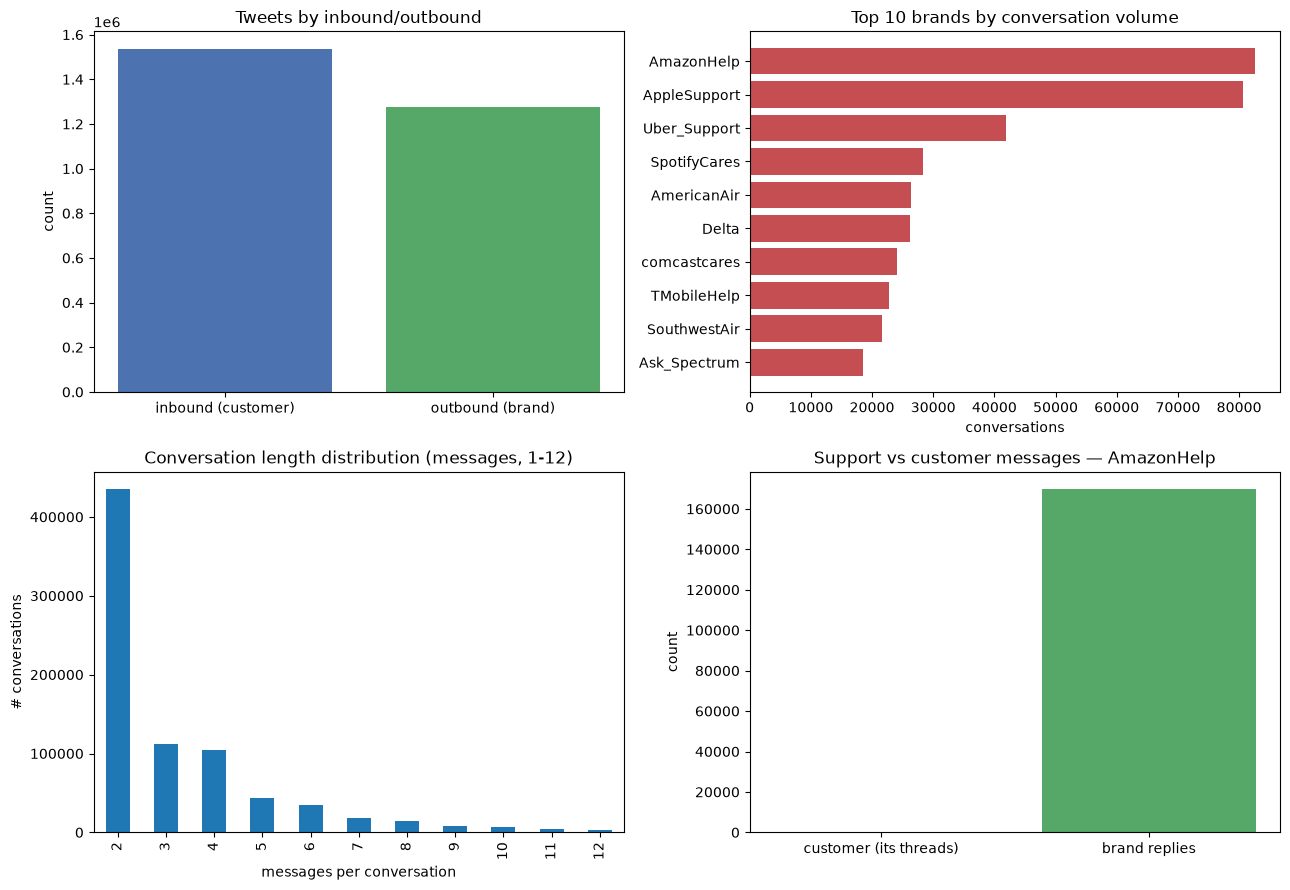

In [22]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8,4)

fig, axes = plt.subplots(2,2, figsize=(13,9))

ax = axes[0,0]
vc = df['inbound'].value_counts().reindex([True,False])
ax.bar(['inbound (customer)','outbound (brand)'], vc.values, color=['#4C72B0','#55A868'])
ax.set_title('Tweets by inbound/outbound'); ax.set_ylabel('count')

ax = axes[0,1]
tp = top.head(10)
ax.barh(tp['Brand'][::-1], tp['Conversations'][::-1], color='#C44E52')
ax.set_title('Top 10 brands by conversation volume'); ax.set_xlabel('conversations')

ax = axes[1,0]
dist = df['conversation_id'].value_counts().value_counts().sort_index()
dist[dist.index<=12].plot(kind='bar', ax=ax)
ax.set_title('Conversation length distribution (messages, 1-12)')
ax.set_xlabel('messages per conversation'); ax.set_ylabel('# conversations')

ax = axes[1,1]
lb = df[df['author_id']==LEAD_BRAND]['inbound'].value_counts().reindex([True,False], fill_value=0)
ax.bar(['customer (its threads)','brand replies'], lb.values, color=['#4C72B0','#55A868'])
ax.set_title(f'Support vs customer messages — {LEAD_BRAND}'); ax.set_ylabel('count')

plt.tight_layout(); plt.show()

/var/folders/m_/wq287mh92735j0r59qknnc8m0000gn/T/ipykernel_75205/2342129124.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly2 = df.groupby(df['dt'].dt.to_period('M')).agg(


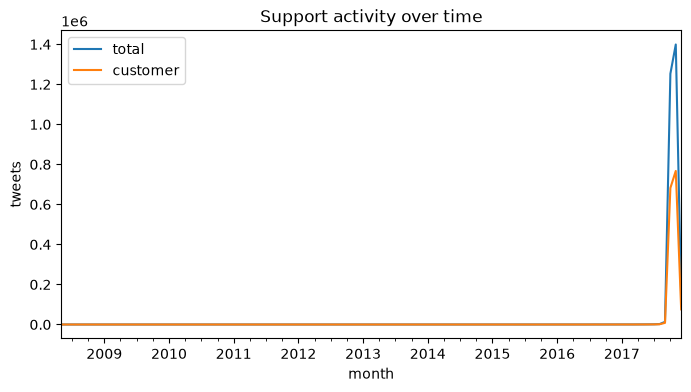

In [23]:
monthly2 = df.groupby(df['dt'].dt.to_period('M')).agg(
    total=('tweet_id','size'), customer=('inbound','sum'))
ax = monthly2.plot()
ax.set_title('Support activity over time')
ax.set_xlabel('month'); ax.set_ylabel('tweets')
plt.show()

## 16. Executive summary & recommendation

In [24]:
print('DATASET')
print('  total records :', f'{df.shape[0]:,}')
print('  date range    :', ts.min(), '->', ts.max())
print('  inbound       :', f'{int(df["inbound"].sum()):,} customer / {int((~df["inbound"]).sum()):,} brand')
print('  recoverable parents:', f'{100*parents.notna().mean():.0f}%')
print('\nBRAND LANDSCAPE')
print('  support accounts:', len(brands), '  total conversations:', f"{df['conversation_id'].nunique():,}")
print('\nTOP-3 RECOMMENDATION (rationale in sec 12):')
for i, r in st.head(3).iterrows():
    print(f'  {int(r["Rank"])}. {r["Brand"]}  convos={int(r["Conversations"]):,}  '
          f'avg-turns={r["Avg turns"]}  intent-pool={int(r["IntentPool"]):,}  overall={r["Overall"]}')

DATASET
  total records : 2,811,774
  date range    : 2008-05-08 20:13:59+00:00 -> 2017-12-03 23:14:01+00:00
  inbound       : 1,537,843 customer / 1,273,931 brand
  recoverable parents: 72%

BRAND LANDSCAPE
  support accounts: 108   total conversations: 798,197

TOP-3 RECOMMENDATION (rationale in sec 12):
  1. AmazonHelp  convos=82,556  avg-turns=4.5  intent-pool=203,598  overall=1.0
  2. Tesco  convos=16,722  avg-turns=4.4  intent-pool=34,228  overall=0.919
  3. AppleSupport  convos=80,717  avg-turns=3.0  intent-pool=131,764  overall=0.915


### Recommended top-3 (rationale)
- **1. AmazonHelp** – the clear all-round winner: highest conversation volume (82.5k) *and*   among the deepest threads (mean 4.5 turns), with a huge pool of customer messages for   intent discovery and rich historical response evidence for retrieval/RAG.
- **2. AppleSupport** – near-identical conversation volume to Amazon (80.7k) and the largest   recognisable brand; slightly shallower threads, but enormous intent diversity across   device/software/battery/account issues with heavily templated (thus learnable) responses.
- **3. Tesco** – lower raw volume but the deepest multi-turn exchanges (mean 4.4, median 4);   a good complement if we want to stress-test multi-turn grounding, though intent diversity   and volume are smaller than Amazon/Apple.

> **Recommended next step (Phase 2):** Deep-dive AmazonHelp (primary) plus AppleSupport and > Tesco (alternates) customer messages via a deterministic sample with TF-IDF/embeddings to > discover the concrete recurring support intents; confirm which brand has the cleanest, most > response-bearing set; and lock the conversation-level split for the golden eval set. Do > **not** build the agent yet.